In [20]:

# AUTOENCODER FINAL PROJECT (UPDATED)


import sys
!{sys.executable} -m pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from io import StringIO

from io import StringIO
import sys
import matplotlib.pyplot as plt

In [21]:
# STEP 3
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

print("Dataset loaded successfully")

In [22]:
# STEP 5
def build_model(size):
    input_layer = Input(shape=(784,))
    
    x = Dense(128, activation='relu')(input_layer)
    x = Dense(64, activation='relu')(x)
    x = Dense(size, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(784, activation='sigmoid')(x)
    
    model = Model(input_layer, output)
    model.compile(optimizer='adam', loss='mse')
    
    return model

In [11]:
# STEP 6
sizes = [16, 32, 64]
loss_values = []

print("\nRunning experiment...")

for size in sizes:
    print("Training with bottleneck =", size)
    
    model = build_model(size)
    
    history = model.fit(
        x_train_flat, x_train_flat,
        epochs=3,
        batch_size=256,
        validation_data=(x_test_flat, x_test_flat),
        verbose=0
    )
    
    loss_values.append(history.history['val_loss'][-1])


Running experiment...
Training with bottleneck = 16
Training with bottleneck = 32
Training with bottleneck = 64


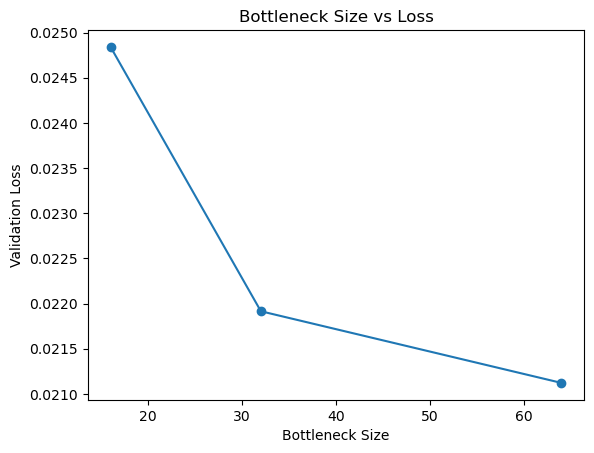

In [23]:
# SAVE GRAPH
plt.figure()
plt.plot(sizes, loss_values, marker='o')
plt.title("Bottleneck Size vs Loss")
plt.xlabel("Bottleneck Size")
plt.ylabel("Validation Loss")
plt.savefig("graph.png")   
plt.show()

In [24]:
# STEP 7
print("\nTraining final model...")

autoencoder = build_model(32)

# Train model
autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=10,
    batch_size=256
)

# =========================================
# SAVE MODEL SUMMARY AS IMAGE (ONLY ONCE)
# =========================================

from io import StringIO
import sys
import matplotlib.pyplot as plt
import os

# Capture summary text (this will NOT print twice)
stream = StringIO()
sys.stdout = stream
autoencoder.summary()
sys.stdout = sys.__stdout__

summary_str = stream.getvalue()

# Create figure
fig = plt.figure(figsize=(14,10))

plt.text(0.01, 0.99, summary_str, fontsize=10, family='monospace', verticalalignment='top')
plt.axis('off')

# Save image
file_path = os.path.join(os.getcwd(), "model_summary.png")
fig.savefig(file_path, bbox_inches='tight', dpi=300)

plt.close(fig)

print(f"✅ Model summary image saved at: {file_path}")

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 667,154 (2.54 MB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444,770 (1.70 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  


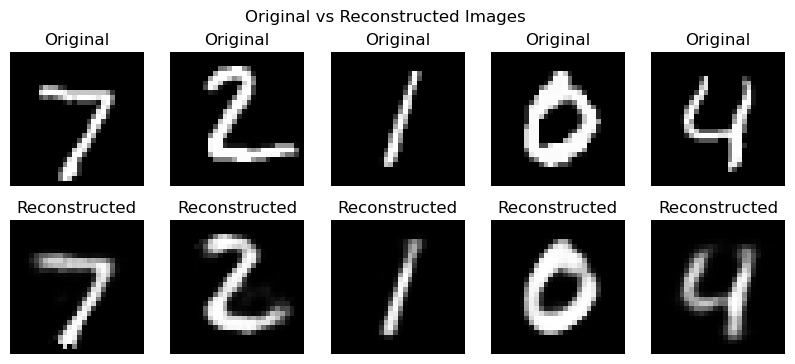

In [7]:
# STEP 8
decoded = autoencoder.predict(x_test_flat)

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(2,5,i+6)
    plt.imshow(decoded[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("Original vs Reconstructed Images")

plt.savefig("reconstruction.png")  
plt.show()